# 05｜自主修改练习：一次只改一个变量

目标不是找出一组“标准答案”，而是留下可复查的实验记录：改了什么、预期什么、结果怎样、证据在哪里。

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import torch

LAB_DIR = Path.cwd()
if not (LAB_DIR / "rnn_lab").is_dir():
    LAB_DIR = (LAB_DIR / "03_rnn_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

# 共享服务器约定：每个 Notebook 只占用一个 CPU 计算线程。
torch.set_num_threads(1)

from dataclasses import replace
import matplotlib.pyplot as plt
from rnn_lab import ExperimentConfig, run_experiment, plot_hidden_states, plot_training_history, print_result_table, configure_chinese_font

## 第一步：运行基线

下面是固定基线。第一次运行时不要改它。

In [2]:
DEVICE = "cpu"
# 获得分配后才可改为 "cuda:x"，x 是指定 GPU 编号。
baseline_config = ExperimentConfig(
    name="基线",
    cell_type="rnn",
    sequence_length=30,
    hidden_size=16,
    epochs=25,
    train_size=600,
    val_size=180,
    test_size=180,
    batch_size=64,
    learning_rate=0.003,
    seed=42,
    device=DEVICE,
)
baseline = run_experiment(baseline_config)
print_result_table([baseline])

模型          长度       准确率       参数量      时间/秒
--------------------------------------------
RNN         30    100.0%       435      0.45


## 第二步：只修改一项

可以选择其中一项：

- `cell_type="lstm"` 或 `"gru"`；
- `sequence_length=60`；
- `hidden_size=32`；
- `learning_rate=0.001`；
- `gradient_clip=None`。

下面默认只把隐藏维度从 16 改成 32。修改前先写一句自己的预期。

实验前预期： 隐藏维度增加后，参数量会增加；准确率是否提高需要看结果。
模型          长度       准确率       参数量      时间/秒
--------------------------------------------
RNN         30    100.0%       435      0.45
RNN         30    100.0%     1,379      0.51


Text(0.5, 0.98, '一次只改一个变量：基线与修改后')

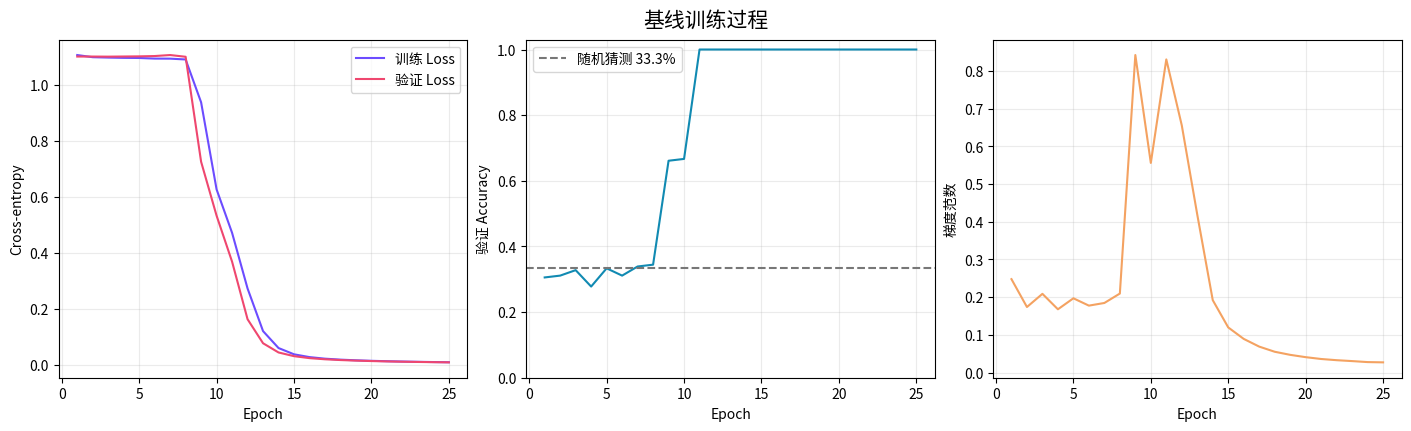

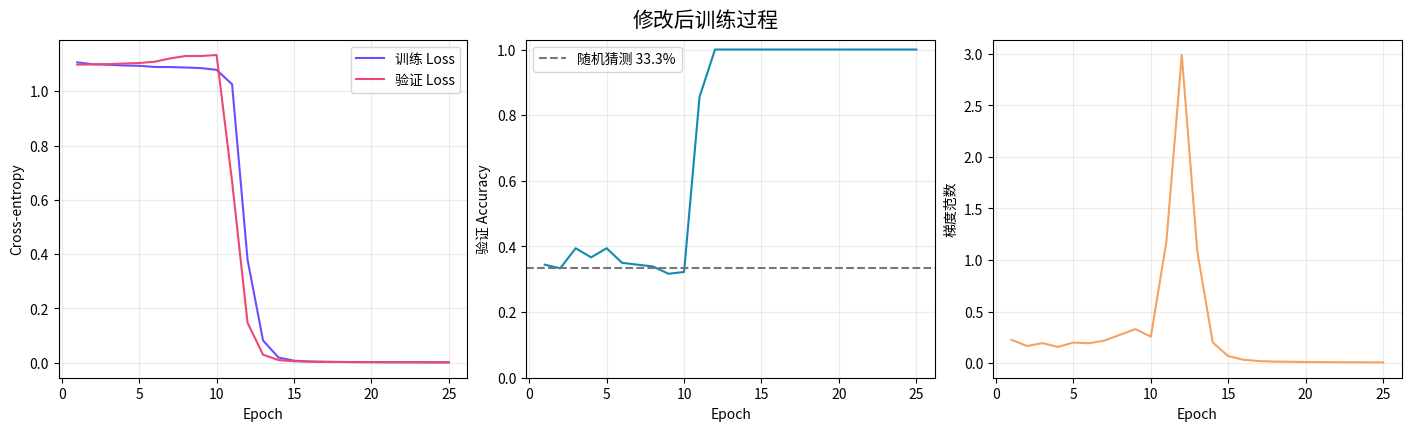

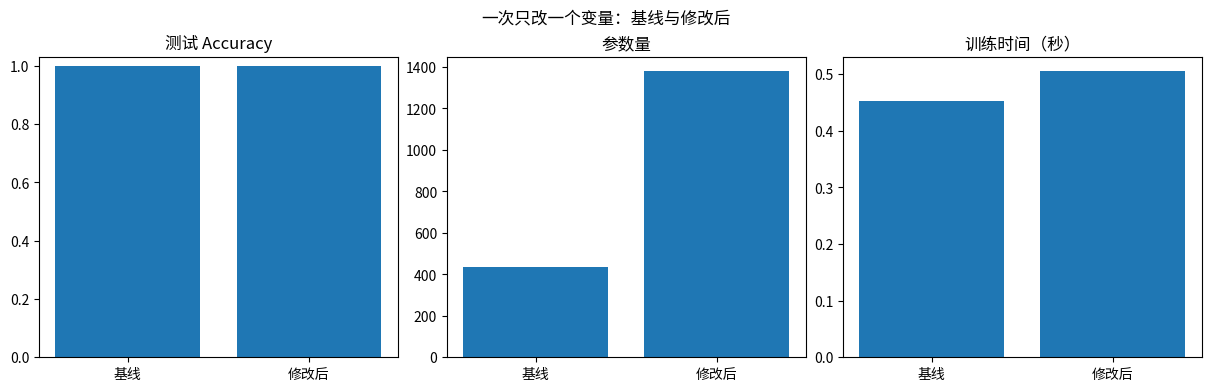

In [3]:
MY_EXPECTATION = "隐藏维度增加后，参数量会增加；准确率是否提高需要看结果。"
changed_config = replace(baseline_config, name="修改后", hidden_size=32)

changed = run_experiment(changed_config)
print("实验前预期：", MY_EXPECTATION)
print_result_table([baseline, changed])

plot_training_history(baseline["history"], title="基线训练过程")
plot_training_history(changed["history"], title="修改后训练过程")

configure_chinese_font()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
labels = ["基线", "修改后"]
axes[0].bar(labels, [baseline["metrics"]["accuracy"], changed["metrics"]["accuracy"]])
axes[0].set_ylim(0, 1.03); axes[0].set_title("测试 Accuracy")
axes[1].bar(labels, [baseline["parameter_count"], changed["parameter_count"]])
axes[1].set_title("参数量")
axes[2].bar(labels, [baseline["elapsed_seconds"], changed["elapsed_seconds"]])
axes[2].set_title("训练时间（秒）")
fig.suptitle("一次只改一个变量：基线与修改后")

## 第三步：填写实验记录

| 项目 | 内容 |
|---|---|
| 保持不变 | 数据规则、随机种子、训练轮数、优化器等 |
| 唯一修改 | 例如 `hidden_size: 16 → 32` |
| 实验前预期 | 运行前写 |
| 数值证据 | Accuracy、参数量、训练时间 |
| 图形证据 | 哪张曲线或柱状图 |
| 有边界的结论 | “在本次配置下……” |

如果同时改变模型、长度和学习率，即使结果提高，也无法判断是哪一项造成的。

## 课程作业｜模型组合小实验（必交）

前面的单变量练习用于熟悉操作；下面是本项目的正式提交区。示例值只保证代码可以运行，提交前请至少更换实验 A 或实验 B 的示例选择，并先写下自己的预测。

### 统一要求

- 总共保留 4 组结果：基线、实验 A、实验 B、组合 A+B；建议用时 60–90 分钟。
- 实验 A 只改变一个**模型因素**，实验 B 只改变一个**训练因素**；数据、随机种子、Epoch、Batch size 和设备保持不变。
- 每次运行前先写预测，再看结果。结果变差不扣分，缺少公平对照或无法解释才扣分。
- 组合 A+B 用来观察两项修改放在一起会怎样；判断单项作用时仍以实验 A、B 为依据。
- 不按 Accuracy 高低排名，也不要通过增加数据量或 Epoch 刷分。
- 只提交完成后的本 Notebook，文件名建议为 `学号_姓名_项目名.ipynb`；无需另交代码压缩包或运行截图。

### 评分建议（100 分）

| 项目 | 分值 |
|---|---:|
| 基线及四组实验完整、Notebook 能按顺序运行 | 15 |
| 单变量控制正确，固定条件说明清楚 | 25 |
| 数值表和至少两项图形证据完整 | 25 |
| 能结合证据解释现象，结论有适用边界 | 25 |
| 参数选择和下一步建议体现自己的思考 | 10 |

### RNN 可选参数与建议

| 类型 | 可选参数 | 建议值 |
|---|---|---|
| 模型因素 A | `cell_type`、`hidden_size` 或 `num_layers` | `rnn/lstm/gru`；`8/16/32`；`1/2` |
| 训练因素 B | `learning_rate` 或 `gradient_clip` | `0.001/0.003/0.01`；`1.0/None` |

**建议：**第一次优先选择“循环单元 + 学习率”。`sequence_length` 会同时改变任务难度，不建议把它作为本次组合因素；可以在报告的“下一步”中把更长序列写成压力测试。前三组只比较最后一轮 Validation Accuracy，组合确定后才在表中显示一次 Test Accuracy。

In [ ]:
# ===== 作业参数区：只修改下面两个字典中的值 =====
MODEL_CHANGE = {"cell_type": "gru"}          # 模型因素 A：只放 1 项
TRAIN_CHANGE = {"learning_rate": 0.001}      # 训练因素 B：只放 1 项

plans = {
    "基线": {},
    "实验 A": MODEL_CHANGE,
    "实验 B": TRAIN_CHANGE,
    "组合 A+B": {**MODEL_CHANGE, **TRAIN_CHANGE},
}

assignment_results = {}
for name, changes in plans.items():
    config = replace(baseline_config, name=name, **changes)
    assignment_results[name] = run_experiment(config)

print("| 实验 | 修改内容 | Validation Accuracy | 参数量 | Test Accuracy |")
print("|---|---|---:|---:|---:|")
for name, result in assignment_results.items():
    changes = plans[name]
    description = "无" if not changes else "；".join(f"{key}={value}" for key, value in changes.items())
    validation = result["history"]["val_accuracy"][-1]
    test_text = f'{result["metrics"]["accuracy"]:.1%}' if name == "组合 A+B" else "不查看"
    print(f"| {name} | {description} | {validation:.1%} | {result['parameter_count']:,} | {test_text} |")

combined = assignment_results["组合 A+B"]
plot_training_history(combined["history"], title="组合 A+B：训练与验证曲线")
plot_hidden_states(combined["model"], combined["data"].x_test, device=DEVICE, title="组合 A+B：隐藏状态")


## 作业报告｜请在提交前填写

请用 **250–400 字** 回答以下问题，并引用上方表格中的具体数值以及至少两项图形证据。

1. 你为实验 A、B 分别选择了什么参数？运行前为什么这样预测？
2. 实验 A 与基线相比发生了什么变化？
3. 实验 B 与基线相比发生了什么变化？
4. 组合 A+B 是否比基线更适合当前任务？依据是什么？
5. 如果再允许运行一次，你准备修改什么？为什么？

### 我的报告

> 请在这里填写。推荐使用“在当前数据、随机种子和训练预算下……”限定结论，避免写成“某种模型永远更好”。

### 提交前自查

- [ ] 四组结果都已运行，且 A、B 各只修改一个因素。
- [ ] 写出了运行前预测，而不是看到结果后补写。
- [ ] 报告引用了具体数值和至少两项图形证据。
- [ ] 没有把运行时间当作评分依据，也没有把一次结果推广到所有数据。
- [ ] 已填写姓名、学号，并按要求命名 Notebook。

## 完成本页后：释放资源并结束内核

运行下面最后一个单元格会清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后 VS Code 显示“内核已停止”或要求重新选择内核属于正常现象。再次实验时重新选择课程内核即可。

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")
get_ipython().kernel.do_shutdown(restart=False)